# ALNS Log Analysis - Comprehensive Visualization

Notebook này phân tích toàn diện các log files từ thuật toán ALNS cho bài toán EVRPTW.

**📊 Các phân tích bao gồm:**
- Tự động quét tất cả instances trong thư mục logs
- Convergence Analysis (Phân tích hội tụ)
- Operator Performance (Hiệu suất toán tử)
- Multi-Instance Comparison
- **Deep Dive cho 1 instance cụ thể**

In [34]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Config
LOG_DIR = Path(r"D:\Work\SLSCM-LaB\24092025\test15\cmake-build-release\logs")

print("✅ Libraries imported successfully!")
print(f"📂 Log Directory: {LOG_DIR}")

✅ Libraries imported successfully!
📂 Log Directory: D:\Work\SLSCM-LaB\24092025\test15\cmake-build-release\logs


## 🔍 Auto-Scan Instances

In [35]:
# Automatically detect all instance directories
def scan_instances(log_dir):
    """Scan and return all instance directories in logs folder"""
    instances = []
    for item in log_dir.iterdir():
        if item.is_dir():
            # Check if it has the expected log files
            progress_file = item / f"{item.name}_progress.csv"
            if progress_file.exists():
                instances.append(item.name)
    return sorted(instances)

INSTANCES = scan_instances(LOG_DIR)

print(f"\n🎯 Detected {len(INSTANCES)} instances:")
for i, inst in enumerate(INSTANCES, 1):
    print(f"  {i}. {inst}")

# Let user choose which instance to focus on for detailed analysis
FOCUS_INSTANCE = INSTANCES[0] if INSTANCES else None  # Default to first
print(f"\n🔍 Default focus instance: {FOCUS_INSTANCE}")
print("💡 You can change this in the 'Focused Analysis' section below")


🎯 Detected 5 instances:
  1. c101_21
  2. r105C15
  3. r107_21
  4. r201_21
  5. rc108C15

🔍 Default focus instance: c101_21
💡 You can change this in the 'Focused Analysis' section below


## 1. 📁 Load All Log Data

In [36]:
def load_instance_data(instance_name):
    """Load all log files for a given instance"""
    instance_dir = LOG_DIR / instance_name
    
    data = {}
    
    # 1. Progress log (convergence data)
    progress_file = instance_dir / f"{instance_name}_progress.csv"
    if progress_file.exists():
        data['progress'] = pd.read_csv(progress_file)
    
    # 2. Operator statistics
    operators_file = instance_dir / f"{instance_name}_operators.csv"
    if operators_file.exists():
        data['operators'] = pd.read_csv(operators_file)
    
    # 3. Pareto front objectives
    front_file = instance_dir / f"{instance_name}_front_objectives.csv"
    if front_file.exists():
        data['front'] = pd.read_csv(front_file)
    
    # 4. Summary
    summary_file = instance_dir / f"{instance_name}_summary.txt"
    if summary_file.exists():
        with open(summary_file, 'r', encoding='utf-8') as f:
            data['summary'] = f.read()
    
    return data

# Load all instances
all_data = {}
for instance in INSTANCES:
    print(f"Loading {instance}...", end=' ')
    all_data[instance] = load_instance_data(instance)
    print("✓")

print(f"\n✅ Loaded data for {len(all_data)} instances")

Loading c101_21... ✓
Loading r105C15... ✓
Loading r107_21... ✓
Loading r201_21... ✓
Loading rc108C15... ✓

✅ Loaded data for 5 instances


## 2. 📈 Convergence Overview (All Instances)

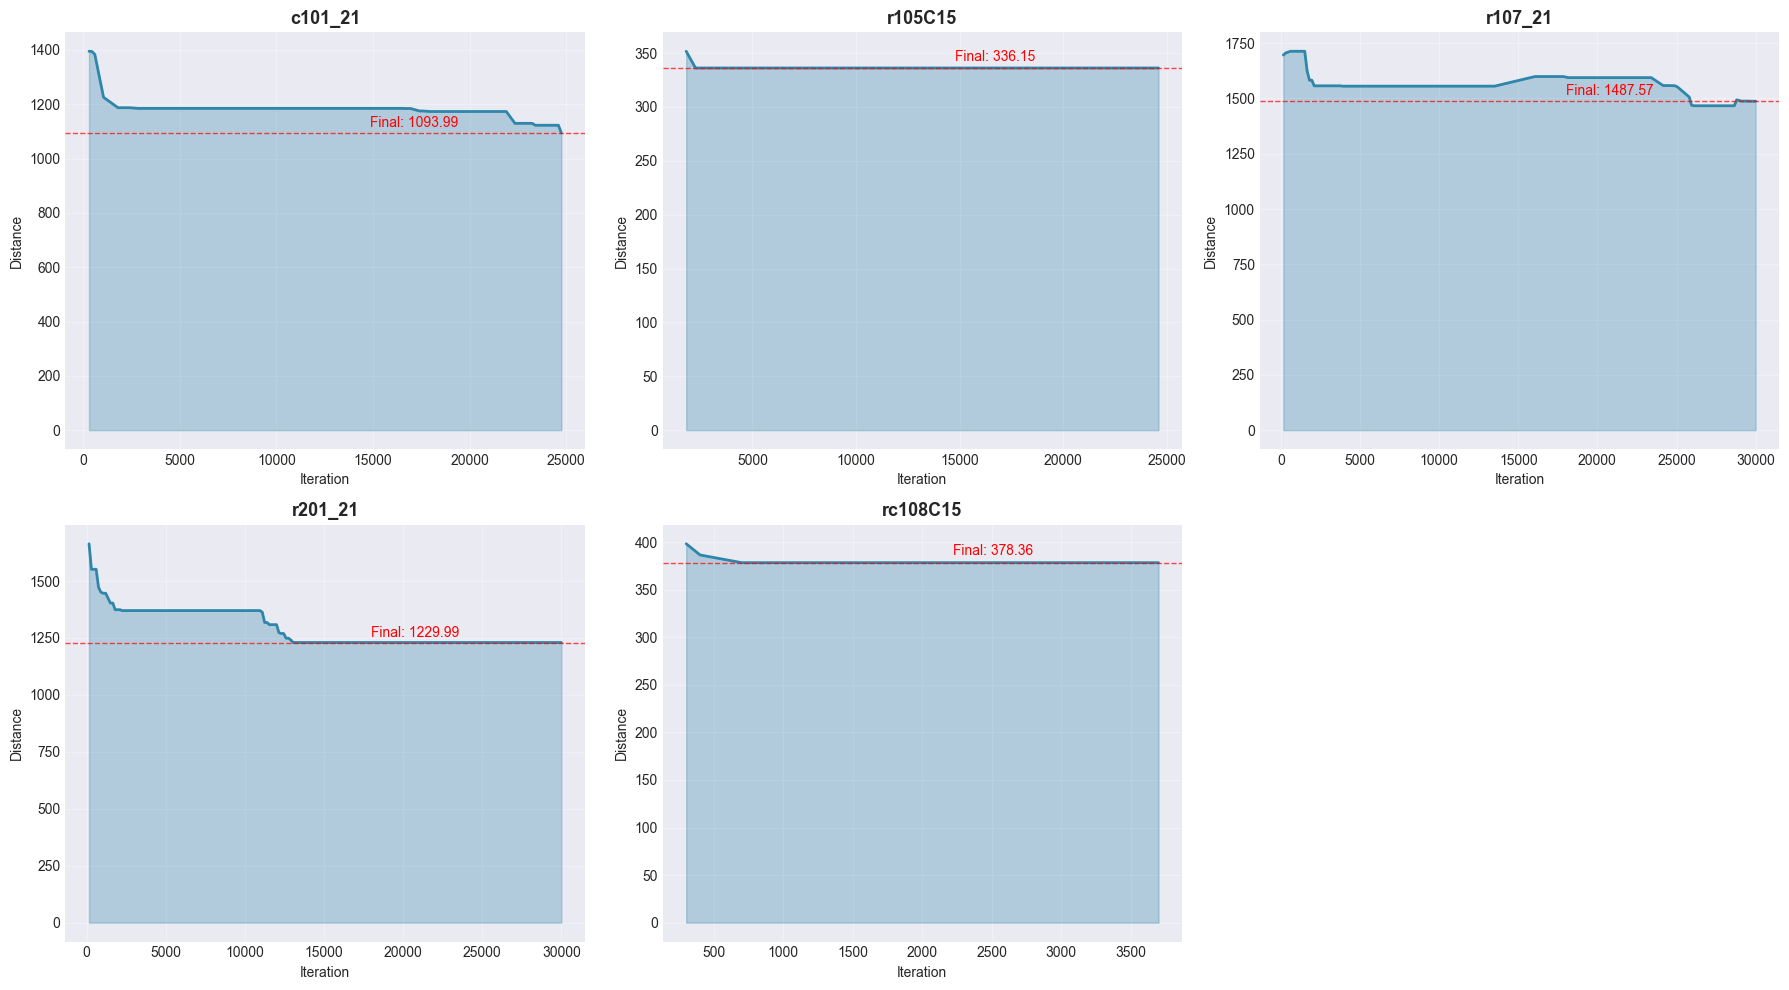

In [37]:
# Dynamic subplot layout based on number of instances
n_instances = len(INSTANCES)
n_cols = 3
n_rows = (n_instances + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() if n_instances > 1 else [axes]

for idx, instance in enumerate(INSTANCES):
    if 'progress' in all_data[instance]:
        df = all_data[instance]['progress']
        
        ax = axes[idx]
        ax.plot(df['Iteration'], df['BestDistance'], linewidth=2, color='#2E86AB')
        ax.fill_between(df['Iteration'], df['BestDistance'], alpha=0.3, color='#2E86AB')
        
        final_dist = df['BestDistance'].iloc[-1]
        ax.axhline(y=final_dist, color='red', linestyle='--', linewidth=1, alpha=0.7)
        ax.text(df['Iteration'].max() * 0.6, final_dist * 1.02, 
                f'Final: {final_dist:.2f}', fontsize=10, color='red')
        
        ax.set_title(f'{instance}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Iteration', fontsize=10)
        ax.set_ylabel('Distance', fontsize=10)
        ax.grid(True, alpha=0.3)

# Remove extra subplots
for idx in range(n_instances, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(LOG_DIR / 'analysis_convergence_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 📊 Multi-Instance Summary Table

In [38]:
# Compile summary table
results = []

for instance in INSTANCES:
    if 'progress' in all_data[instance]:
        df = all_data[instance]['progress']
        final_row = df.iloc[-1]
        initial_row = df.iloc[0]
        
        results.append({
            'Instance': instance,
            'Initial Dist': initial_row['BestDistance'],
            'Final Dist': final_row['BestDistance'],
            'Improvement': initial_row['BestDistance'] - final_row['BestDistance'],
            'Improvement %': ((initial_row['BestDistance'] - final_row['BestDistance']) / initial_row['BestDistance']) * 100,
            'Vehicles': int(final_row['BestVehicles']),
            'Iterations': int(final_row['Iteration']),
            'Time (s)': final_row['Timestamp_ms'] / 1000
        })

results_df = pd.DataFrame(results)

print("\n" + "="*100)
print("📊 SUMMARY - ALL INSTANCES")
print("="*100)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.2f}'))
print("="*100)

# Save to CSV
results_df.to_csv(LOG_DIR / 'SUMMARY_ALL_INSTANCES.csv', index=False)
print(f"\n✅ Saved to: {LOG_DIR / 'SUMMARY_ALL_INSTANCES.csv'}")


📊 SUMMARY - ALL INSTANCES
Instance  Initial Dist  Final Dist  Improvement  Improvement %  Vehicles  Iterations  Time (s)
 c101_21       1395.10     1093.99       301.11          21.58        12       24750     65.34
 r105C15        351.66      336.15        15.51           4.41         4       24600     14.45
 r107_21       1696.29     1487.57       208.72          12.30        13       30000    120.83
 r201_21       1663.51     1229.99       433.53          26.06         4       30000    475.95
rc108C15        398.22      378.36        19.86           4.99         3        3700      1.82

✅ Saved to: D:\Work\SLSCM-LaB\24092025\test15\cmake-build-release\logs\SUMMARY_ALL_INSTANCES.csv


---
# 🎯 FOCUSED ANALYSIS - Detailed Deep Dive

Phần này dành riêng cho **1 instance cụ thể** mà bạn muốn phân tích chi tiết.

In [39]:
# ====================================================================
# 🔧 CONFIGURATION: Chọn instance muốn phân tích chi tiết
# ====================================================================

FOCUS_INSTANCE = 'rc108C15'  # <-- THAY ĐỔI TÊN Ở ĐÂY

# Verify instance exists
if FOCUS_INSTANCE not in INSTANCES:
    print(f"⚠️  Instance '{FOCUS_INSTANCE}' not found!")
    print(f"Available instances: {INSTANCES}")
    FOCUS_INSTANCE = INSTANCES[0] if INSTANCES else None
    print(f"Falling back to: {FOCUS_INSTANCE}")

print(f"\n{'='*70}")
print(f"🎯 FOCUSED ANALYSIS: {FOCUS_INSTANCE}")
print(f"{'='*70}\n")

# Load focused data
focus_data = all_data[FOCUS_INSTANCE]
focus_progress = focus_data.get('progress')
focus_operators = focus_data.get('operators')
focus_front = focus_data.get('front')

print(f"✅ Data loaded for {FOCUS_INSTANCE}")
print(f"   - Progress entries: {len(focus_progress) if focus_progress is not None else 0}")
print(f"   - Operator entries: {len(focus_operators) if focus_operators is not None else 0}")
print(f"   - Pareto solutions: {len(focus_front) if focus_front is not None else 0}")


🎯 FOCUSED ANALYSIS: rc108C15

✅ Data loaded for rc108C15
   - Progress entries: 23
   - Operator entries: 276
   - Pareto solutions: 2


## 🔍 Cell 1: Detailed Convergence Analysis

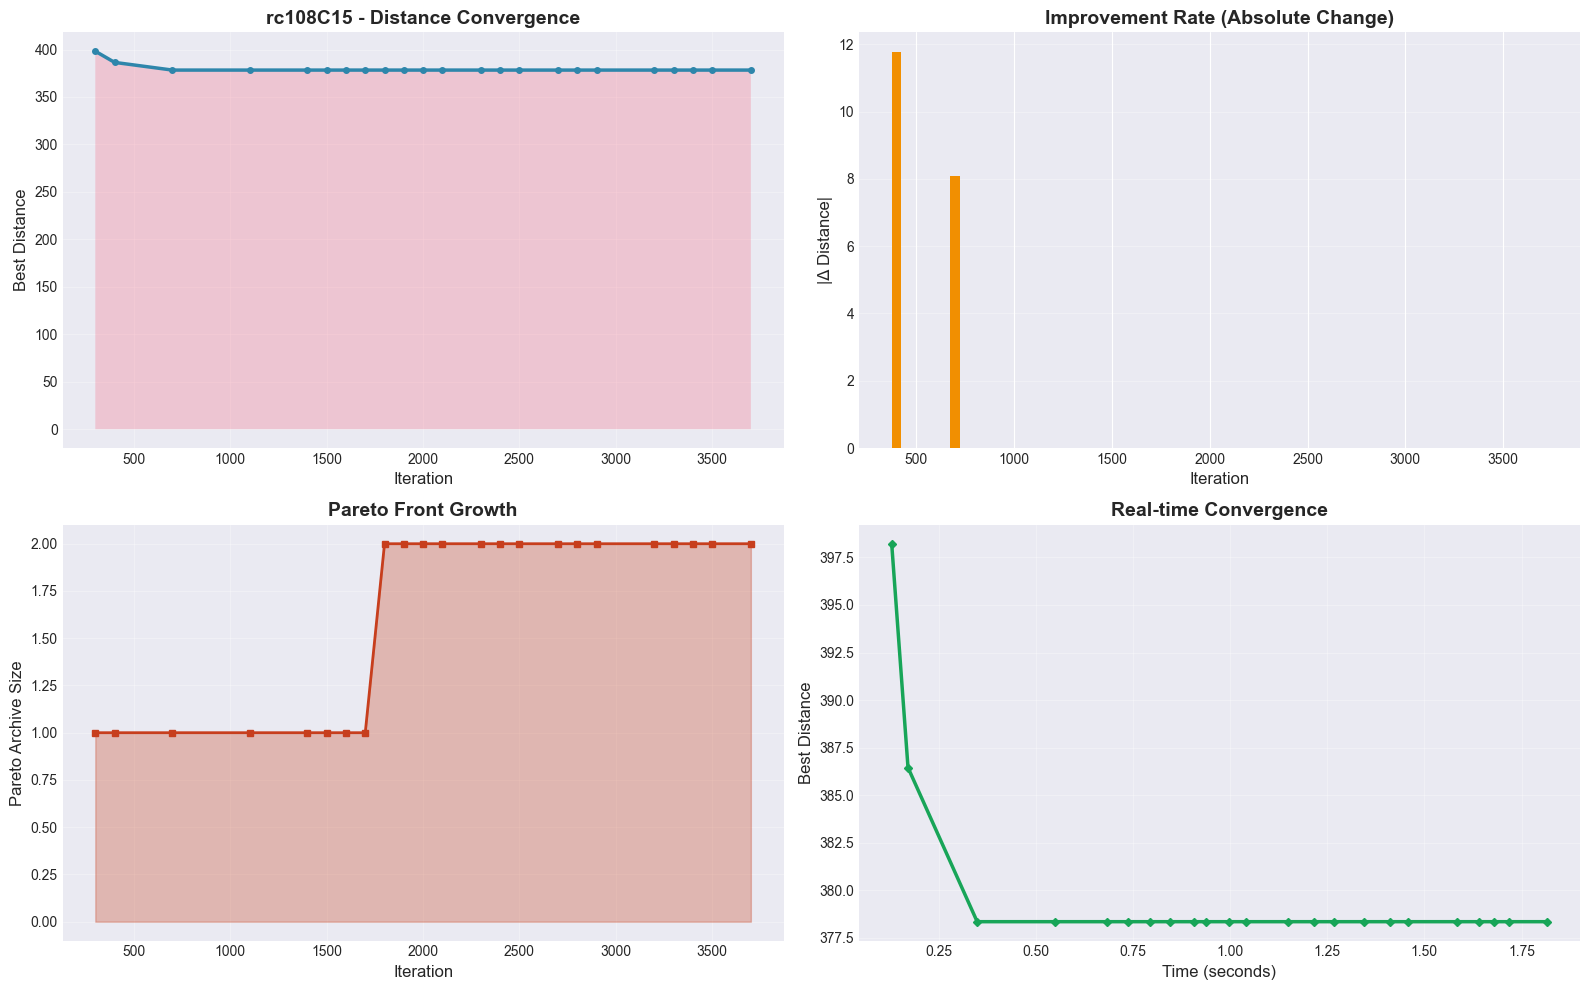


📊 Convergence Statistics:
   Initial Distance: 398.22
   Final Distance: 378.36
   Total Improvement: 19.86
   Total Runtime: 1.8 seconds

⚠️  Stagnation detected at iteration 700 (18.9%)


In [40]:
if focus_progress is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Distance over iterations
    ax1 = axes[0, 0]
    ax1.plot(focus_progress['Iteration'], focus_progress['BestDistance'], 
             linewidth=2.5, color='#2E86AB', marker='o', markersize=4)
    ax1.fill_between(focus_progress['Iteration'], focus_progress['BestDistance'], alpha=0.3)
    ax1.set_xlabel('Iteration', fontsize=12)
    ax1.set_ylabel('Best Distance', fontsize=12)
    ax1.set_title(f'{FOCUS_INSTANCE} - Distance Convergence', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # 2. Distance improvement rate (delta)
    ax2 = axes[0, 1]
    distance_delta = focus_progress['BestDistance'].diff().abs()
    ax2.bar(focus_progress['Iteration'], distance_delta, color='#F18F01', width=50)
    ax2.set_xlabel('Iteration', fontsize=12)
    ax2.set_ylabel('|Δ Distance|', fontsize=12)
    ax2.set_title('Improvement Rate (Absolute Change)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Archive size evolution
    ax3 = axes[1, 0]
    ax3.plot(focus_progress['Iteration'], focus_progress['ArchiveSize'], 
             linewidth=2, color='#C73E1D', marker='s', markersize=5)
    ax3.fill_between(focus_progress['Iteration'], focus_progress['ArchiveSize'], alpha=0.3, color='#C73E1D')
    ax3.set_xlabel('Iteration', fontsize=12)
    ax3.set_ylabel('Pareto Archive Size', fontsize=12)
    ax3.set_title('Pareto Front Growth', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # 4. Time efficiency (distance vs time)
    ax4 = axes[1, 1]
    time_s = focus_progress['Timestamp_ms'] / 1000
    ax4.plot(time_s, focus_progress['BestDistance'], 
             linewidth=2.5, color='#18A558', marker='D', markersize=4)
    ax4.set_xlabel('Time (seconds)', fontsize=12)
    ax4.set_ylabel('Best Distance', fontsize=12)
    ax4.set_title('Real-time Convergence', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(LOG_DIR / f'focused_{FOCUS_INSTANCE}_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print(f"\n📊 Convergence Statistics:")
    print(f"   Initial Distance: {focus_progress['BestDistance'].iloc[0]:.2f}")
    print(f"   Final Distance: {focus_progress['BestDistance'].iloc[-1]:.2f}")
    print(f"   Total Improvement: {focus_progress['BestDistance'].iloc[0] - focus_progress['BestDistance'].iloc[-1]:.2f}")
    print(f"   Total Runtime: {time_s.iloc[-1]:.1f} seconds")
    
    # Detect stagnation
    final_dist = focus_progress['BestDistance'].iloc[-1]
    stagnation_mask = (focus_progress['BestDistance'] - final_dist).abs() < 0.01
    if stagnation_mask.any():
        stagnation_iter = focus_progress.loc[stagnation_mask, 'Iteration'].iloc[0]
        total_iters = focus_progress['Iteration'].iloc[-1]
        print(f"\n⚠️  Stagnation detected at iteration {stagnation_iter} ({stagnation_iter/total_iters*100:.1f}%)")
else:
    print("⚠️ No progress data available")

## 🎯 Cell 2: Operator Deep Dive

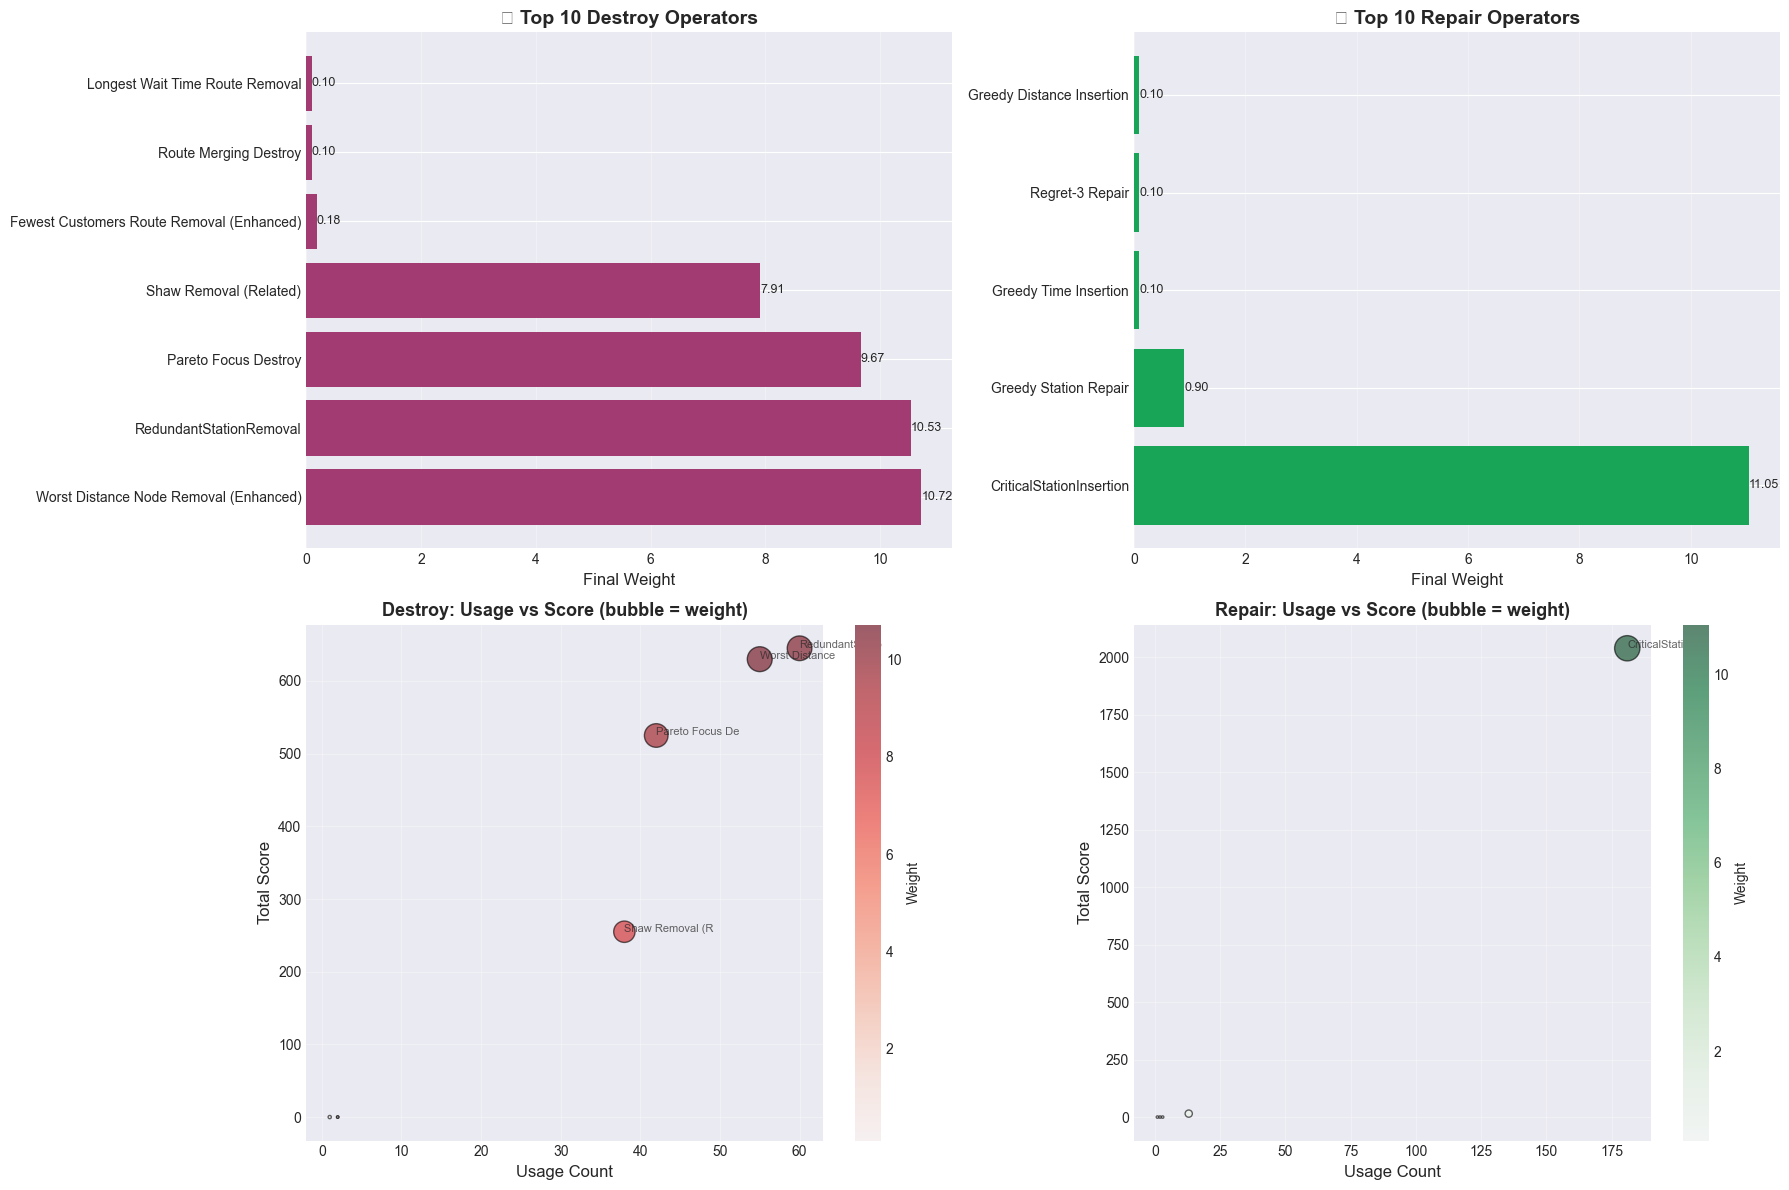


🏆 Top 3 Destroy Operators:
   Worst Distance Node Removal (Enhanced): Weight=10.72, Score=630
   RedundantStationRemoval: Weight=10.53, Score=645
   Pareto Focus Destroy: Weight=9.67, Score=525

🏆 Top 3 Repair Operators:
   CriticalStationInsertion: Weight=11.05, Score=2040
   Greedy Station Repair: Weight=0.90, Score=15
   Greedy Time Insertion: Weight=0.10, Score=0


In [41]:
if focus_operators is not None:
    # Get final operator stats
    final_segment = focus_operators['Segment'].max()
    final_ops = focus_operators[focus_operators['Segment'] == final_segment].copy()
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Top Destroy Operators
    ax1 = axes[0, 0]
    destroy = final_ops[final_ops['Type'] == 'Destroy'].sort_values('Weight', ascending=False).head(10)
    bars1 = ax1.barh(destroy['OperatorName'], destroy['Weight'], color='#A23B72')
    ax1.set_xlabel('Final Weight', fontsize=12)
    ax1.set_title('🔨 Top 10 Destroy Operators', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    for bar in bars1:
        width = bar.get_width()
        ax1.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
                ha='left', va='center', fontsize=9)
    
    # 2. Top Repair Operators
    ax2 = axes[0, 1]
    repair = final_ops[final_ops['Type'] == 'Repair'].sort_values('Weight', ascending=False).head(10)
    bars2 = ax2.barh(repair['OperatorName'], repair['Weight'], color='#18A558')
    ax2.set_xlabel('Final Weight', fontsize=12)
    ax2.set_title('🔧 Top 10 Repair Operators', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    for bar in bars2:
        width = bar.get_width()
        ax2.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
                ha='left', va='center', fontsize=9)
    
    # 3. Usage Count vs Score (Destroy)
    ax3 = axes[1, 0]
    destroy_all = final_ops[final_ops['Type'] == 'Destroy']
    scatter1 = ax3.scatter(destroy_all['UsageCount'], destroy_all['Score'], 
                          s=destroy_all['Weight']*30, alpha=0.6, c=destroy_all['Weight'], 
                          cmap='Reds', edgecolors='black', linewidth=1)
    for idx, row in destroy_all.iterrows():
        if row['Weight'] > 5:  # Only label high-weight operators
            ax3.annotate(row['OperatorName'][:15], (row['UsageCount'], row['Score']), 
                        fontsize=8, alpha=0.7)
    ax3.set_xlabel('Usage Count', fontsize=12)
    ax3.set_ylabel('Total Score', fontsize=12)
    ax3.set_title('Destroy: Usage vs Score (bubble = weight)', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=ax3, label='Weight')
    
    # 4. Usage Count vs Score (Repair)
    ax4 = axes[1, 1]
    repair_all = final_ops[final_ops['Type'] == 'Repair']
    scatter2 = ax4.scatter(repair_all['UsageCount'], repair_all['Score'], 
                          s=repair_all['Weight']*30, alpha=0.6, c=repair_all['Weight'], 
                          cmap='Greens', edgecolors='black', linewidth=1)
    for idx, row in repair_all.iterrows():
        if row['Weight'] > 5:
            ax4.annotate(row['OperatorName'][:15], (row['UsageCount'], row['Score']), 
                        fontsize=8, alpha=0.7)
    ax4.set_xlabel('Usage Count', fontsize=12)
    ax4.set_ylabel('Total Score', fontsize=12)
    ax4.set_title('Repair: Usage vs Score (bubble = weight)', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=ax4, label='Weight')
    
    plt.tight_layout()
    plt.savefig(LOG_DIR / f'focused_{FOCUS_INSTANCE}_operators.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print top performers
    print(f"\n🏆 Top 3 Destroy Operators:")
    for idx, row in destroy.head(3).iterrows():
        print(f"   {row['OperatorName']}: Weight={row['Weight']:.2f}, Score={row['Score']:.0f}")
    
    print(f"\n🏆 Top 3 Repair Operators:")
    for idx, row in repair.head(3).iterrows():
        print(f"   {row['OperatorName']}: Weight={row['Weight']:.2f}, Score={row['Score']:.0f}")
else:
    print("⚠️ No operator data available")

## 📈 Cell 3: Operator Weight Evolution Heatmap

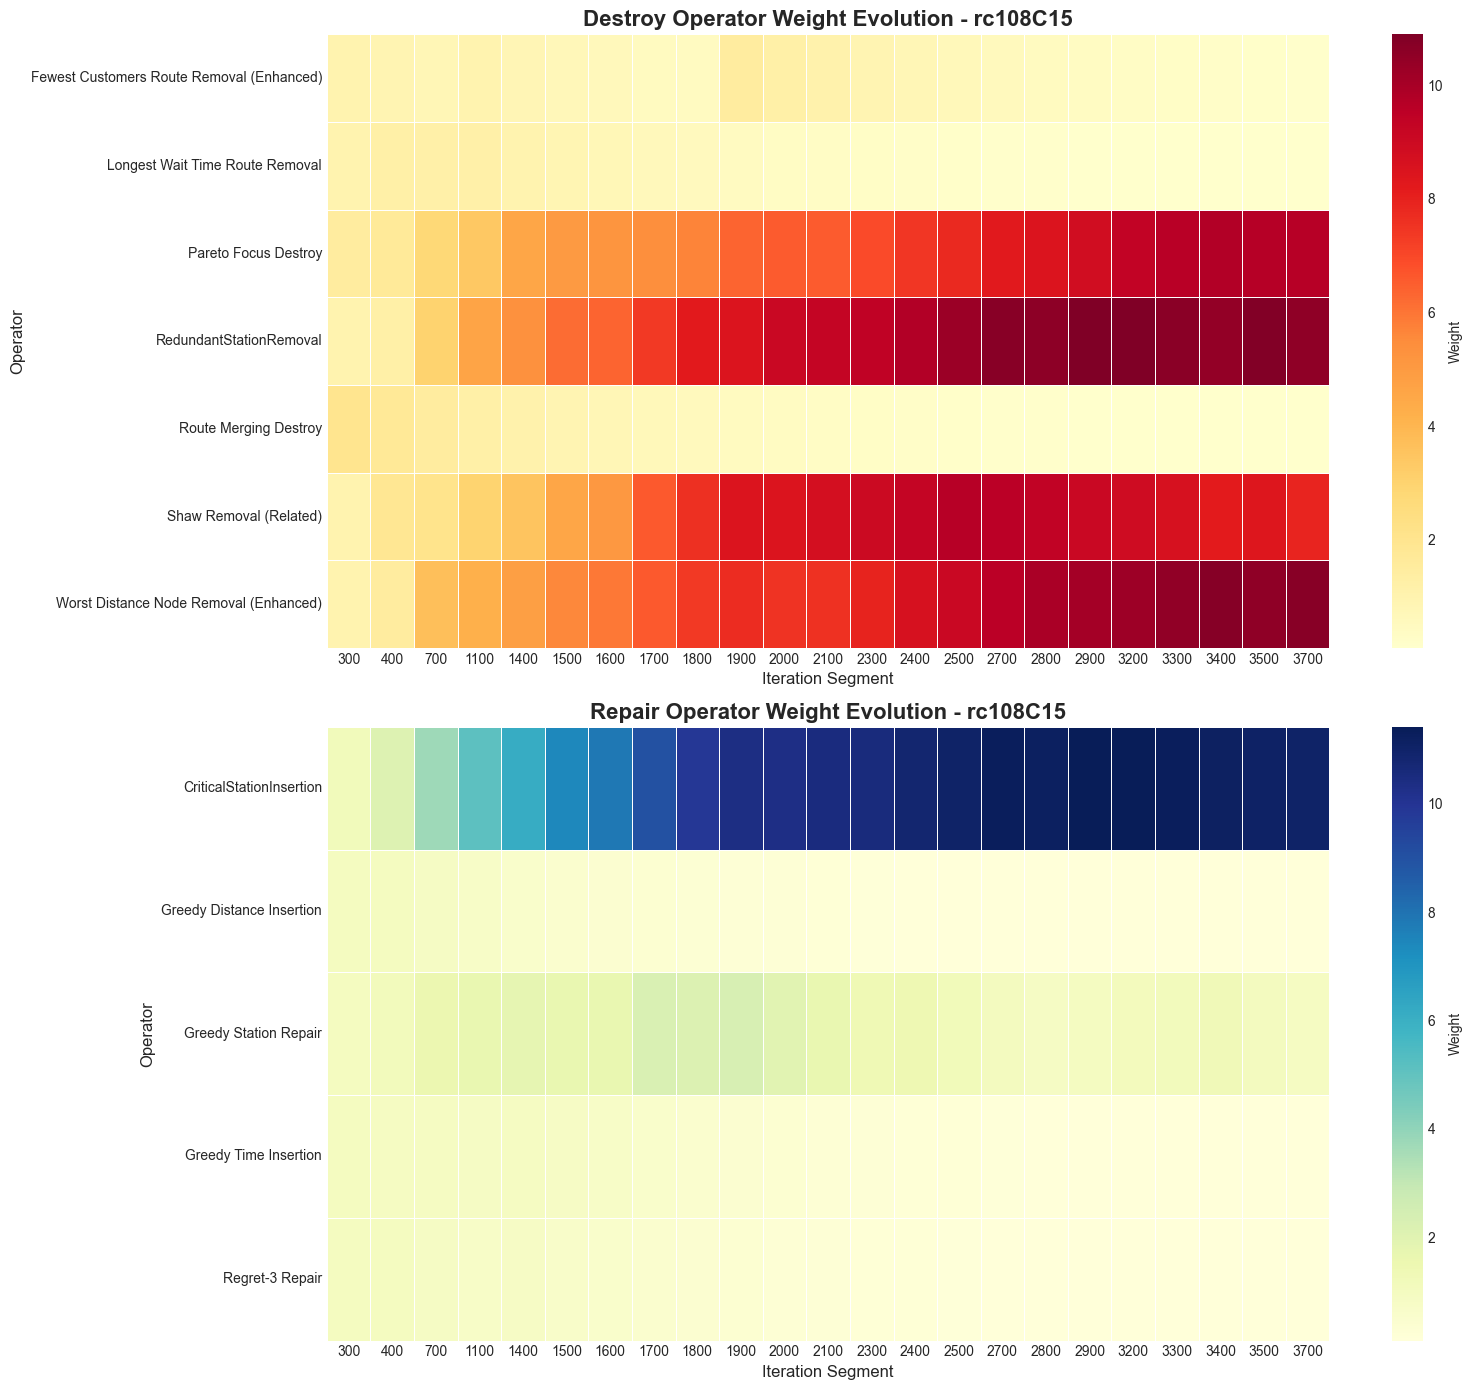

✅ Heatmaps show how operator weights adapted over time


In [42]:
if focus_operators is not None:
    # Create separate heatmaps for Destroy and Repair
    fig, axes = plt.subplots(2, 1, figsize=(16, 14))
    
    # Destroy operators heatmap
    destroy_ops = focus_operators[focus_operators['Type'] == 'Destroy']
    pivot_destroy = destroy_ops.pivot_table(index='OperatorName', columns='Segment', 
                                           values='Weight', aggfunc='mean')
    
    ax1 = axes[0]
    sns.heatmap(pivot_destroy, cmap='YlOrRd', annot=False, fmt='.2f', 
                linewidths=0.5, cbar_kws={'label': 'Weight'}, ax=ax1)
    ax1.set_title(f'Destroy Operator Weight Evolution - {FOCUS_INSTANCE}', 
                 fontsize=16, fontweight='bold')
    ax1.set_xlabel('Iteration Segment', fontsize=12)
    ax1.set_ylabel('Operator', fontsize=12)
    
    # Repair operators heatmap
    repair_ops = focus_operators[focus_operators['Type'] == 'Repair']
    pivot_repair = repair_ops.pivot_table(index='OperatorName', columns='Segment', 
                                          values='Weight', aggfunc='mean')
    
    ax2 = axes[1]
    sns.heatmap(pivot_repair, cmap='YlGnBu', annot=False, fmt='.2f', 
                linewidths=0.5, cbar_kws={'label': 'Weight'}, ax=ax2)
    ax2.set_title(f'Repair Operator Weight Evolution - {FOCUS_INSTANCE}', 
                 fontsize=16, fontweight='bold')
    ax2.set_xlabel('Iteration Segment', fontsize=12)
    ax2.set_ylabel('Operator', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(LOG_DIR / f'focused_{FOCUS_INSTANCE}_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✅ Heatmaps show how operator weights adapted over time")
else:
    print("⚠️ No operator data available")

## 📝 Final Summary for Focused Instance

In [43]:
print(f"\n{'='*80}")
print(f"📋 COMPREHENSIVE SUMMARY: {FOCUS_INSTANCE}")
print(f"{'='*80}\n")

if focus_progress is not None:
    initial = focus_progress.iloc[0]
    final = focus_progress.iloc[-1]
    
    print(f"🎯 CONVERGENCE:")
    print(f"   Initial Distance: {initial['BestDistance']:.2f}")
    print(f"   Final Distance: {final['BestDistance']:.2f}")
    print(f"   Improvement: {initial['BestDistance'] - final['BestDistance']:.2f} ({((initial['BestDistance'] - final['BestDistance'])/initial['BestDistance'])*100:.2f}%)")
    print(f"   Total Iterations: {int(final['Iteration'])}")
    print(f"   Runtime: {final['Timestamp_ms']/1000:.1f} seconds")
    print(f"   Vehicles Used: {int(final['BestVehicles'])}")

if focus_operators is not None:
    final_segment = focus_operators['Segment'].max()
    final_ops = focus_operators[focus_operators['Segment'] == final_segment]
    
    best_destroy = final_ops[final_ops['Type'] == 'Destroy'].nlargest(1, 'Weight').iloc[0]
    best_repair = final_ops[final_ops['Type'] == 'Repair'].nlargest(1, 'Weight').iloc[0]
    
    print(f"\n🔨 BEST OPERATORS:")
    print(f"   Destroy: {best_destroy['OperatorName']} (Weight: {best_destroy['Weight']:.2f})")
    print(f"   Repair: {best_repair['OperatorName']} (Weight: {best_repair['Weight']:.2f})")

if focus_front is not None:
    print(f"\n📊 PARETO FRONT:")
    print(f"   Solutions: {len(focus_front)}")
    if len(focus_front) > 0:
        best_dist = focus_front.nsmallest(1, 'TotalDistance').iloc[0]
        print(f"   Best Distance Solution: {best_dist['TotalDistance']:.2f} (Vehicles: {int(best_dist['TotalVehicles'])})")

print(f"\n{'='*80}")

# Save focused analysis summary
with open(LOG_DIR / f'FOCUSED_ANALYSIS_{FOCUS_INSTANCE}.txt', 'w', encoding='utf-8') as f:
    f.write(f"Focused Analysis Summary: {FOCUS_INSTANCE}\n")
    f.write(f"Generated: {pd.Timestamp.now()}\n\n")
    if focus_progress is not None:
        f.write(f"Final Distance: {final['BestDistance']:.2f}\n")
        f.write(f"Vehicles: {int(final['BestVehicles'])}\n")
        f.write(f"Iterations: {int(final['Iteration'])}\n")

print(f"\n✅ Summary saved to: {LOG_DIR / f'FOCUSED_ANALYSIS_{FOCUS_INSTANCE}.txt'}")


📋 COMPREHENSIVE SUMMARY: rc108C15

🎯 CONVERGENCE:
   Initial Distance: 398.22
   Final Distance: 378.36
   Improvement: 19.86 (4.99%)
   Total Iterations: 3700
   Runtime: 1.8 seconds
   Vehicles Used: 3

🔨 BEST OPERATORS:
   Destroy: Worst Distance Node Removal (Enhanced) (Weight: 10.72)
   Repair: CriticalStationInsertion (Weight: 11.05)

📊 PARETO FRONT:
   Solutions: 2
   Best Distance Solution: 378.36 (Vehicles: 3)


✅ Summary saved to: D:\Work\SLSCM-LaB\24092025\test15\cmake-build-release\logs\FOCUSED_ANALYSIS_rc108C15.txt
